# Task 1


In [46]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   fixed acidity         4898 non-null   object
 1   volatile acidity      4898 non-null   object
 2   citric acid           4898 non-null   object
 3   residual sugar        4898 non-null   object
 4   chlorides             4898 non-null   object
 5   free sulfur dioxide   4898 non-null   object
 6   total sulfur dioxide  4898 non-null   object
 7   density               4898 non-null   object
 8   pH                    4898 non-null   object
 9   sulphates             4898 non-null   object
 10  alcohol               4898 non-null   object
dtypes: object(11)
memory usage: 421.0+ KB
     fixed acidity volatile acidity citric acid residual sugar chlorides  \
0              7.0             0.27        0.36           20.7     0.045   
1              6.3              0.3        0.34 

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


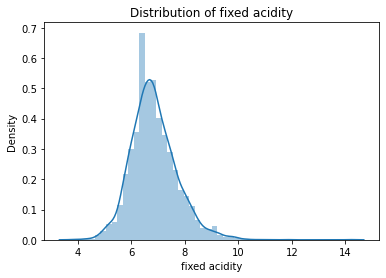

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


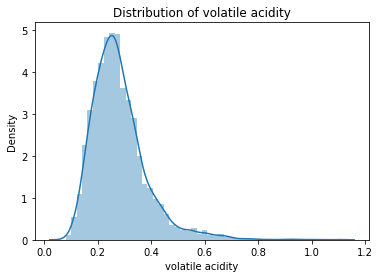

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


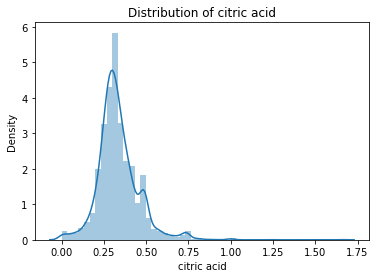

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


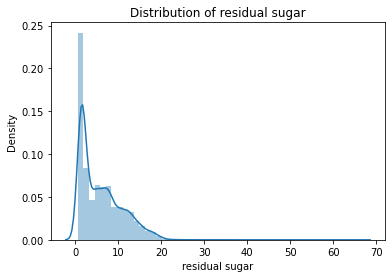

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


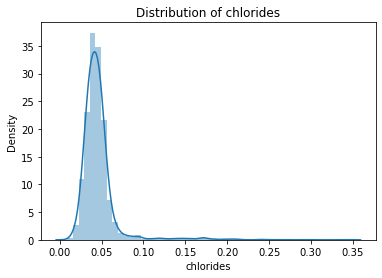

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


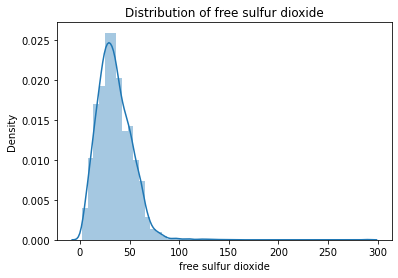

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


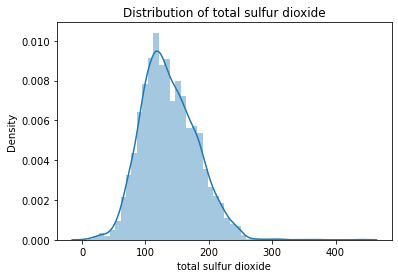

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


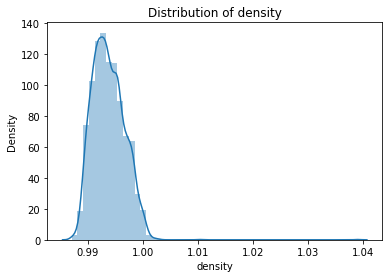

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


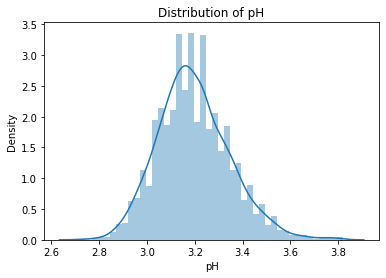

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


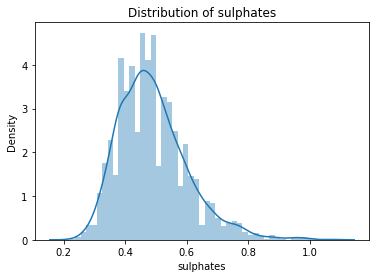

c:\Users\Tom\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


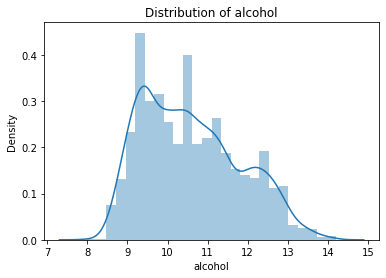

In [51]:
## data cleaning



df = pd.read_csv('./CAB330_asm2_datasets/CAB330_asm2_datasets/Dataset4Task1_26.csv', na_filter=False)
df.info()


# check for duplicates
print(df[df.duplicated(keep=False)])
print("#### dupe check ####")
dupe_count = df.duplicated().sum()
print(dupe_count)

# export to observe duplicate entries
duplicates = df[df.duplicated(keep=False)]
duplicates = duplicates.sort_values(by=list(df.columns))
duplicates.to_excel('dupes.xlsx')


# convert data type from object to float. 
# conversion failed because of empty string entries
# scan to see number of empty strings

print("\n### Search for empty string entry ###")
count = 0
total_count = 0

for col in df.columns:
    count = (df[col] == '').sum()
    total_count += count
    if (count != 0):
        print(f"*{col}* empty count: {count}")
print(f"total empty count: {total_count}")

# convert empty entry into NaN

df = df.replace('', np.nan)

print("\n#### Check for NaN values ####")
null_count = 0
for col in df.columns:
    temp_count = df[col].isna().sum()
    null_count += temp_count

print(null_count)


# application of data cleaning process
df = df.drop_duplicates()
print("\n#### Duplication removal check ####")
dupe_count = df.duplicated().sum()
print(dupe_count)  # confirmed to have zero duplication

# change data type to float
df = df.astype(float)
df.info()

# addressing NaN values
to_be_deleted = []
for index, row in df.iterrows():
    row_null = 0
    for column in df.columns:
        if (pd.isna(row[column])):
            row_null += 1

    if row_null >= 2:
        to_be_deleted.append(index)
print(to_be_deleted)

# graph plot for each data point
for col in df.columns:

    sns.distplot(df[col].dropna())
    plt.title(f"Distribution of {col}")
    plt.show()

#fill with median
df = df.fillna(df.median())
